# Regularization Comparison Report

This notebook compares several regularization strategies on MNIST.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

COMPARISON_DIR = Path(r"C:\Users\emil_\vscode\Assignment1\part_2\outputs\regularization_comparison_2026-04-28_155225")
RUN_NAMES = ['baseline', 'dropout_only', 'batchnorm_only', 'weight_decay_only', 'l1_only', 'combined_regularization']
RUN_DIRS = {'baseline': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\regularization_comparison_2026-04-28_155225\\baseline', 'dropout_only': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\regularization_comparison_2026-04-28_155225\\dropout_only', 'batchnorm_only': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\regularization_comparison_2026-04-28_155225\\batchnorm_only', 'weight_decay_only': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\regularization_comparison_2026-04-28_155225\\weight_decay_only', 'l1_only': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\regularization_comparison_2026-04-28_155225\\l1_only', 'combined_regularization': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_2\\outputs\\regularization_comparison_2026-04-28_155225\\combined_regularization'}

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


## Summary Table

In [2]:
rows = []
for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    config = load_json(run_dir / 'config.json')
    summary = load_json(run_dir / 'summary.json')
    rows.append({
        'run': run_name,
        'model': config['model_name'],
        'dropout': config.get('dropout', 0.0),
        'batch_norm': config.get('batch_norm', False),
        'weight_decay': config.get('weight_decay', 0.0),
        'l1_lambda': config.get('l1_lambda', 0.0),
        'input_noise_std': config.get('input_noise_std', 0.0),
        'test_acc': summary['final_test_accuracy'],
        'best_val_acc': summary['best_validation_accuracy'],
        'best_val_loss': summary['best_validation_loss'],
        'time_s': summary['total_training_time_seconds'],
    })
rows

[{'run': 'baseline',
  'model': 'cnn_medium',
  'dropout': 0.0,
  'batch_norm': False,
  'weight_decay': 0.0,
  'l1_lambda': 0.0,
  'input_noise_std': 0.0,
  'test_acc': 0.9909,
  'best_val_acc': 0.9903333333333333,
  'best_val_loss': 0.0350444634432594,
  'time_s': 52.88391770000089},
 {'run': 'dropout_only',
  'model': 'cnn_dropout',
  'dropout': 0.3,
  'batch_norm': False,
  'weight_decay': 0.0,
  'l1_lambda': 0.0,
  'input_noise_std': 0.0,
  'test_acc': 0.9921,
  'best_val_acc': 0.9901666666666666,
  'best_val_loss': 0.03634824275442709,
  'time_s': 58.019742500000575},
 {'run': 'batchnorm_only',
  'model': 'cnn_batchnorm',
  'dropout': 0.1,
  'batch_norm': True,
  'weight_decay': 0.0,
  'l1_lambda': 0.0,
  'input_noise_std': 0.0,
  'test_acc': 0.9913,
  'best_val_acc': 0.9916666666666667,
  'best_val_loss': 0.02931958390135939,
  'time_s': 67.14809989999776},
 {'run': 'weight_decay_only',
  'model': 'cnn_medium',
  'dropout': 0.0,
  'batch_norm': False,
  'weight_decay': 0.0001,
 

## Pandas Overview

In [3]:
df = pd.DataFrame(rows)
display_columns = [
    'run',
    'model',
    'dropout',
    'batch_norm',
    'weight_decay',
    'l1_lambda',
    'input_noise_std',
    'best_val_loss',
    'best_val_acc',
    'test_acc',
    'time_s',
]
df[display_columns].sort_values(by='test_acc', ascending=False).reset_index(drop=True)

,run,model,dropout,batch_norm,weight_decay,l1_lambda,input_noise_std,best_val_loss,best_val_acc,test_acc,time_s
0,dropout_only,cnn_dropout,0.30,False,0.0000,0.000000,0.00,0.036348,0.990167,0.9921,58.019743
1,batchnorm_only,cnn_batchnorm,0.10,True,0.0000,0.000000,0.00,0.029320,0.991667,0.9913,67.148100
2,l1_only,cnn_medium,0.00,False,0.0000,0.000001,0.00,0.034472,0.989000,0.9913,62.591064
3,baseline,cnn_medium,0.00,False,0.0000,0.000000,0.00,0.035044,0.990333,0.9909,52.883918
4,combined_regularization,cnn_regularized,0.25,True,0.0001,0.000001,0.05,0.028649,0.990500,0.9901,74.551234
5,weight_decay_only,cnn_medium,0.00,False,0.0001,0.000000,0.00,0.036970,0.988667,0.9899,54.937168


## Interpretation

Regularization methods mainly help by reducing overfitting and making optimization more stable. Dropout randomly removes features during training, weight decay discourages very large weights, batch normalization stabilizes activations across mini-batches, and input noise injection makes the model less sensitive to small perturbations.

In [4]:
best_run = max(rows, key=lambda row: row['test_acc'])
fastest_run = min(rows, key=lambda row: row['time_s'])
{'best_test_run': best_run, 'fastest_run': fastest_run}

{'best_test_run': {'run': 'dropout_only',
  'model': 'cnn_dropout',
  'dropout': 0.3,
  'batch_norm': False,
  'weight_decay': 0.0,
  'l1_lambda': 0.0,
  'input_noise_std': 0.0,
  'test_acc': 0.9921,
  'best_val_acc': 0.9901666666666666,
  'best_val_loss': 0.03634824275442709,
  'time_s': 58.019742500000575},
 'fastest_run': {'run': 'baseline',
  'model': 'cnn_medium',
  'dropout': 0.0,
  'batch_norm': False,
  'weight_decay': 0.0,
  'l1_lambda': 0.0,
  'input_noise_std': 0.0,
  'test_acc': 0.9909,
  'best_val_acc': 0.9903333333333333,
  'best_val_loss': 0.0350444634432594,
  'time_s': 52.88391770000089}}

## Saved Plots


## baseline


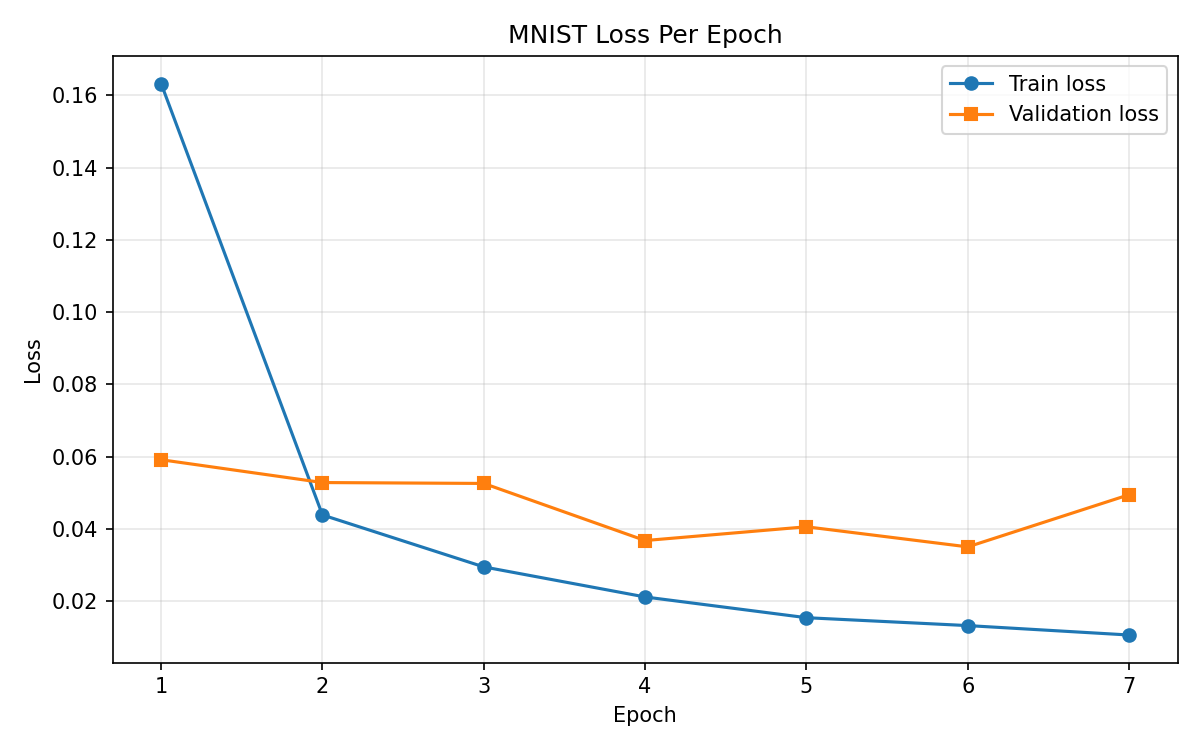

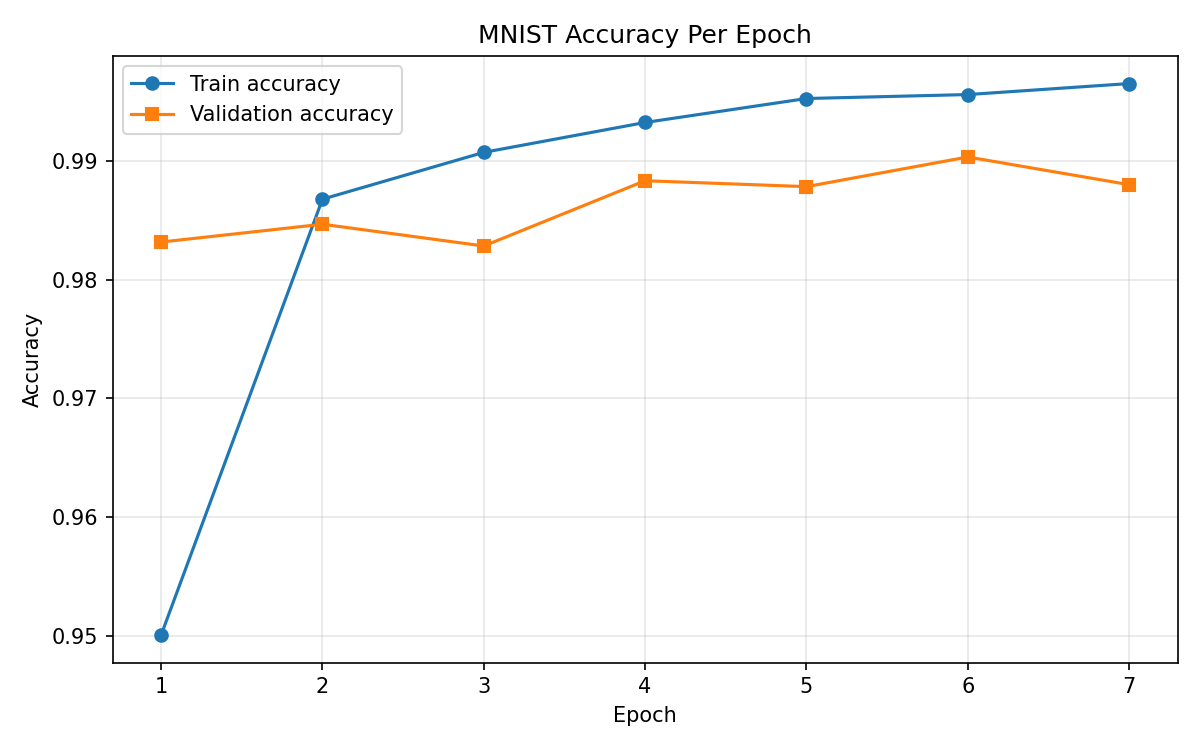

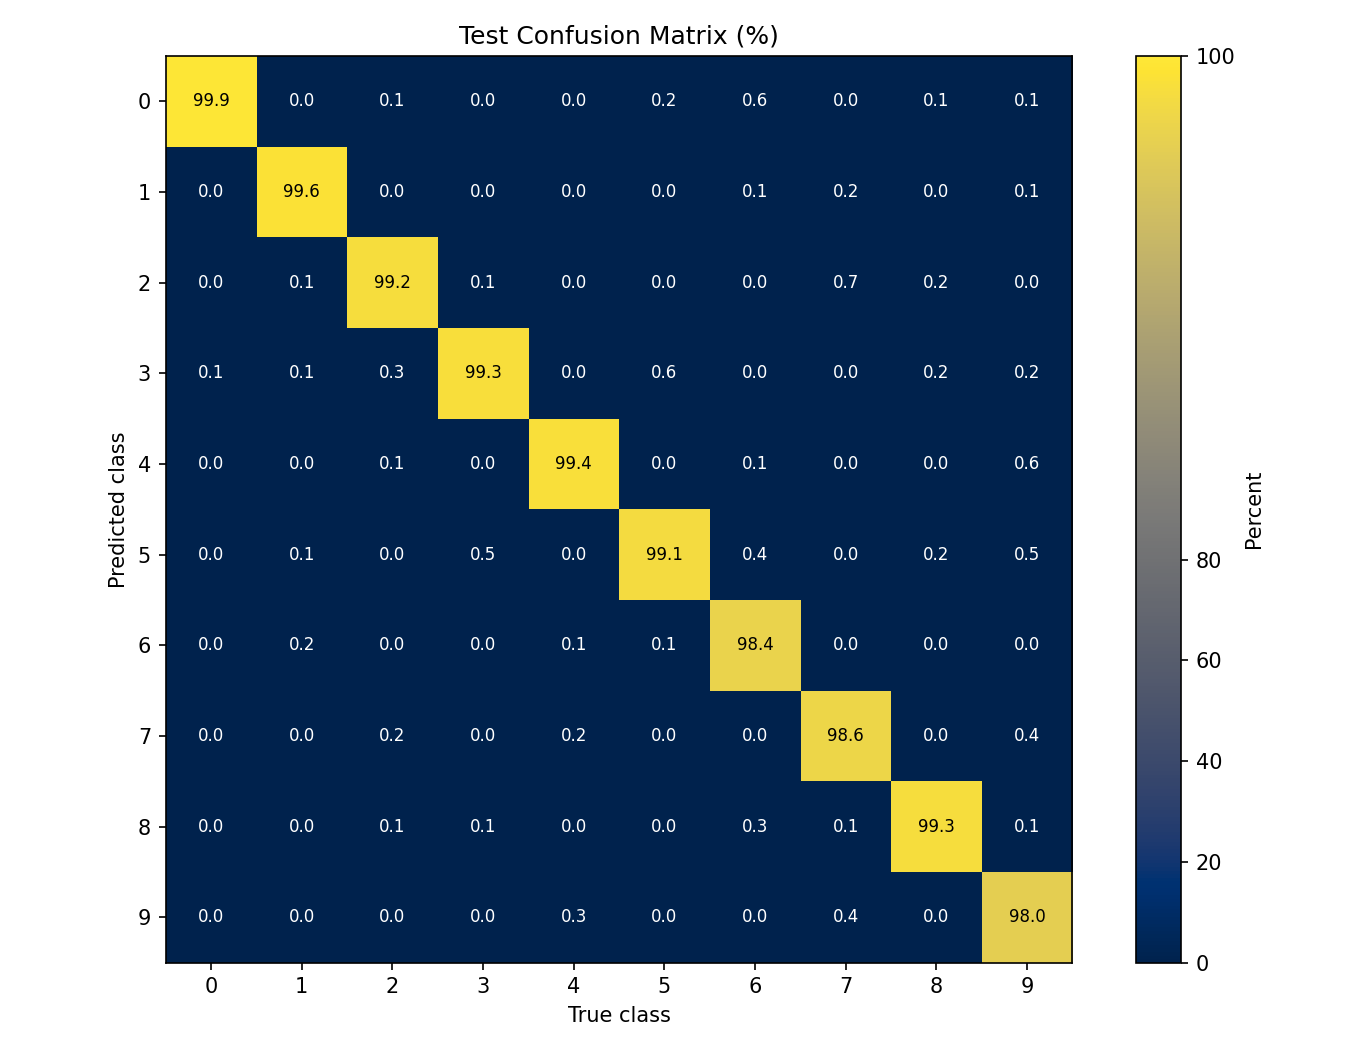


## dropout_only


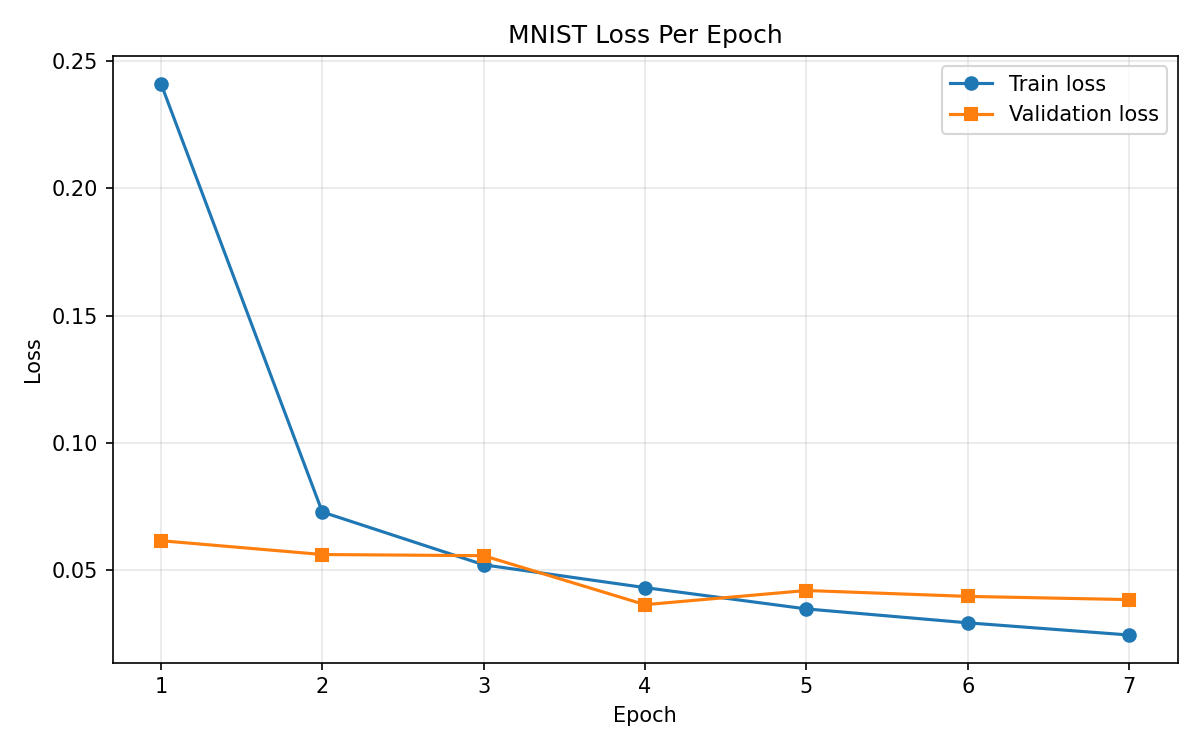

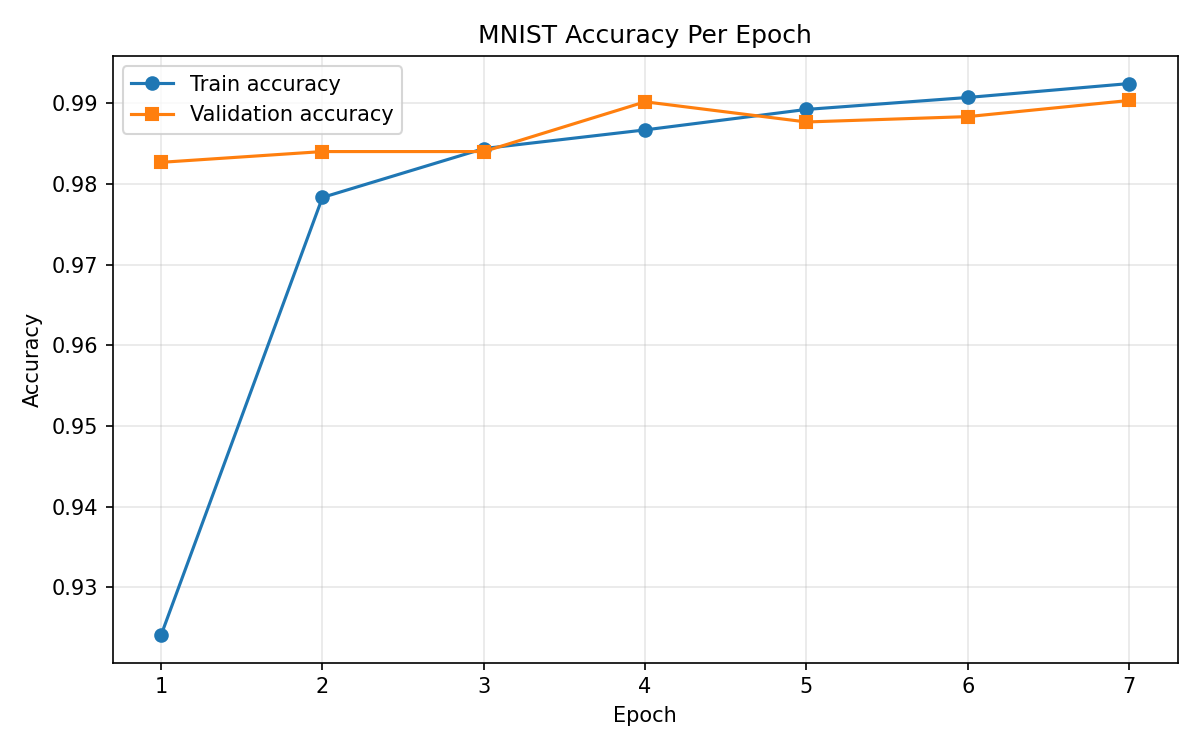

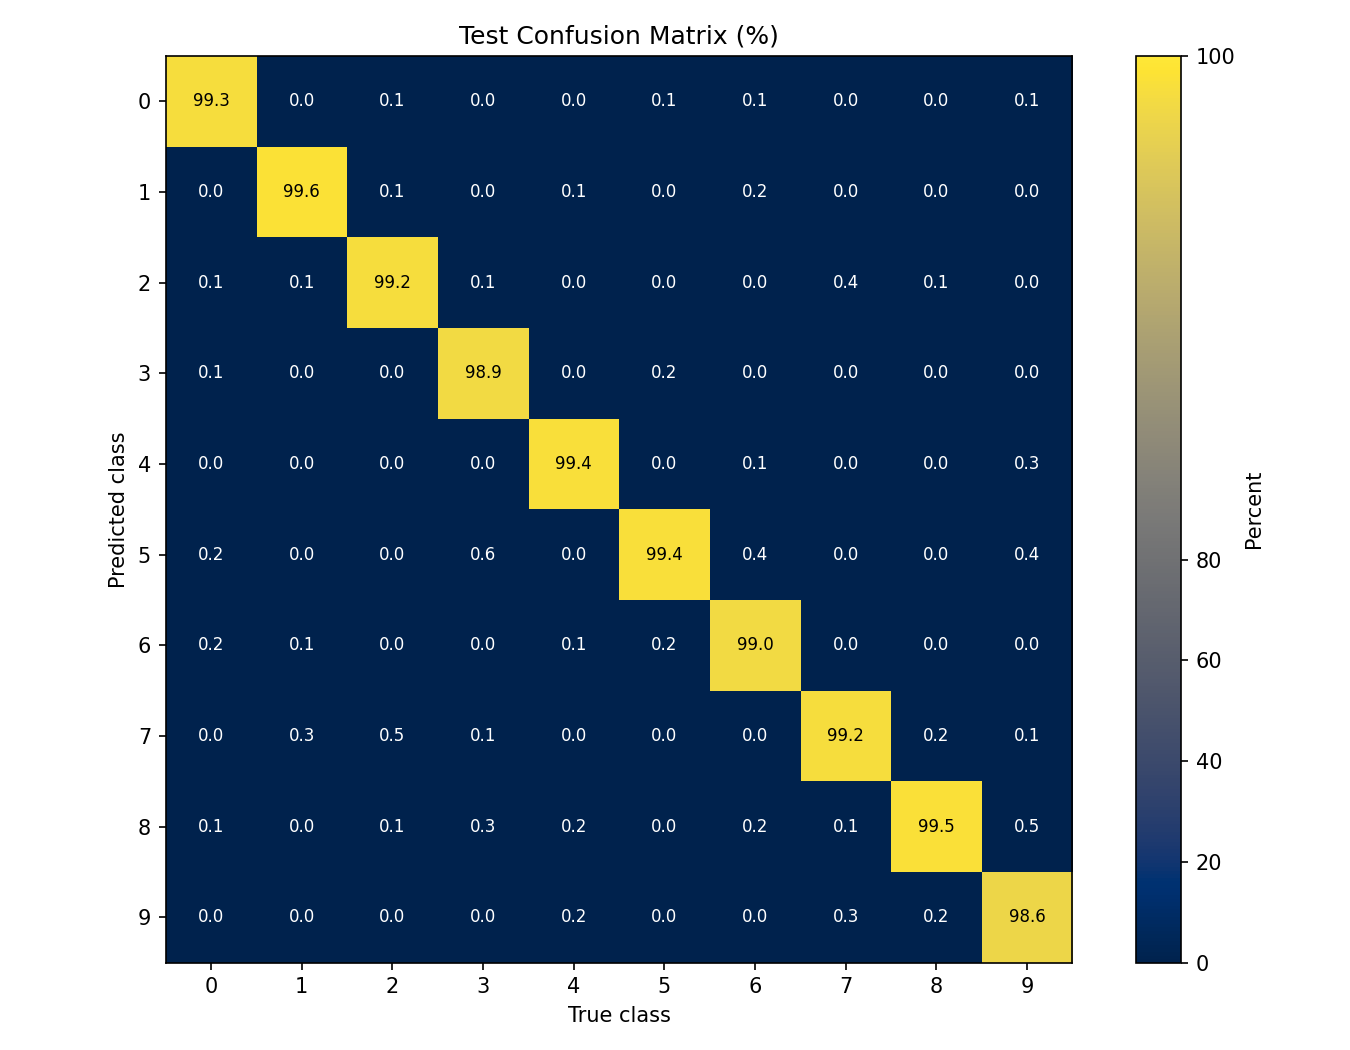


## batchnorm_only


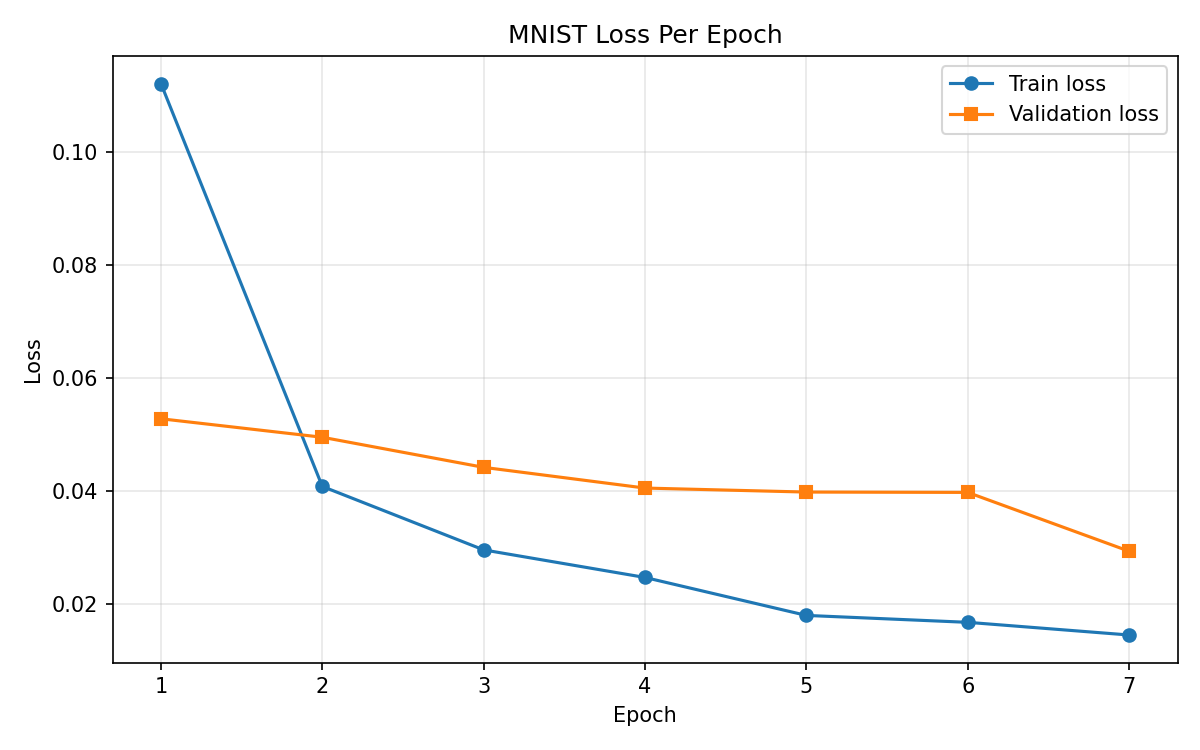

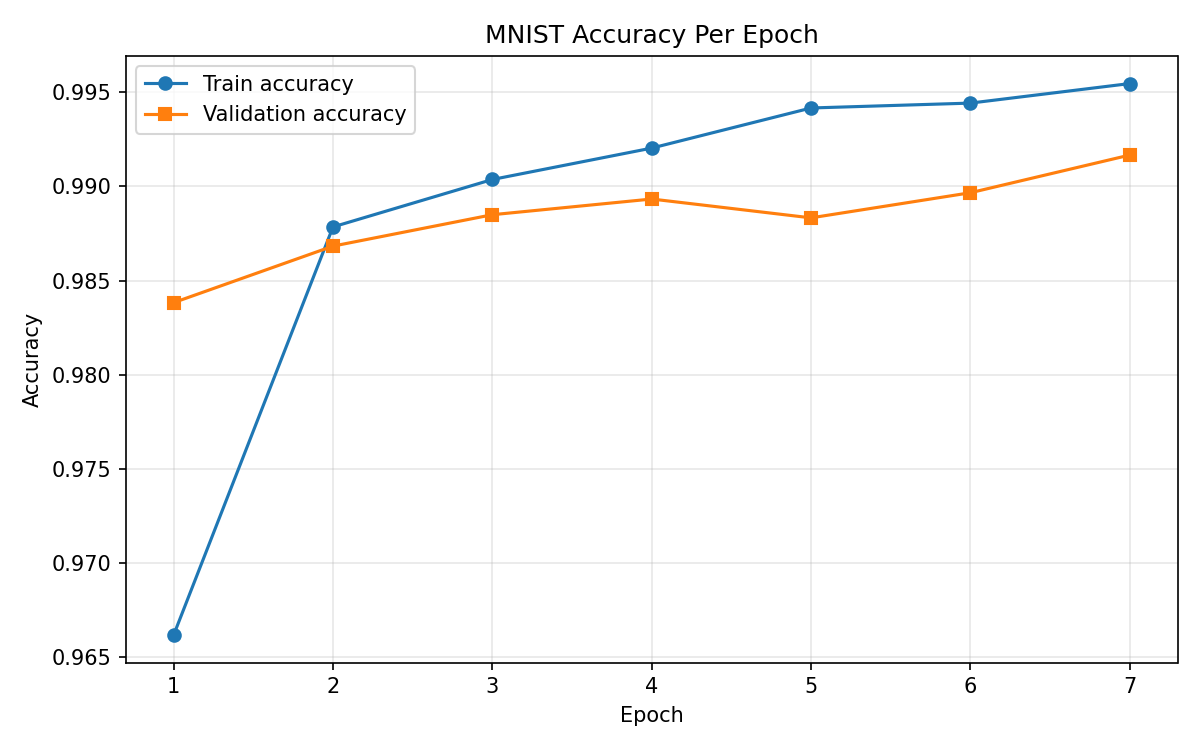

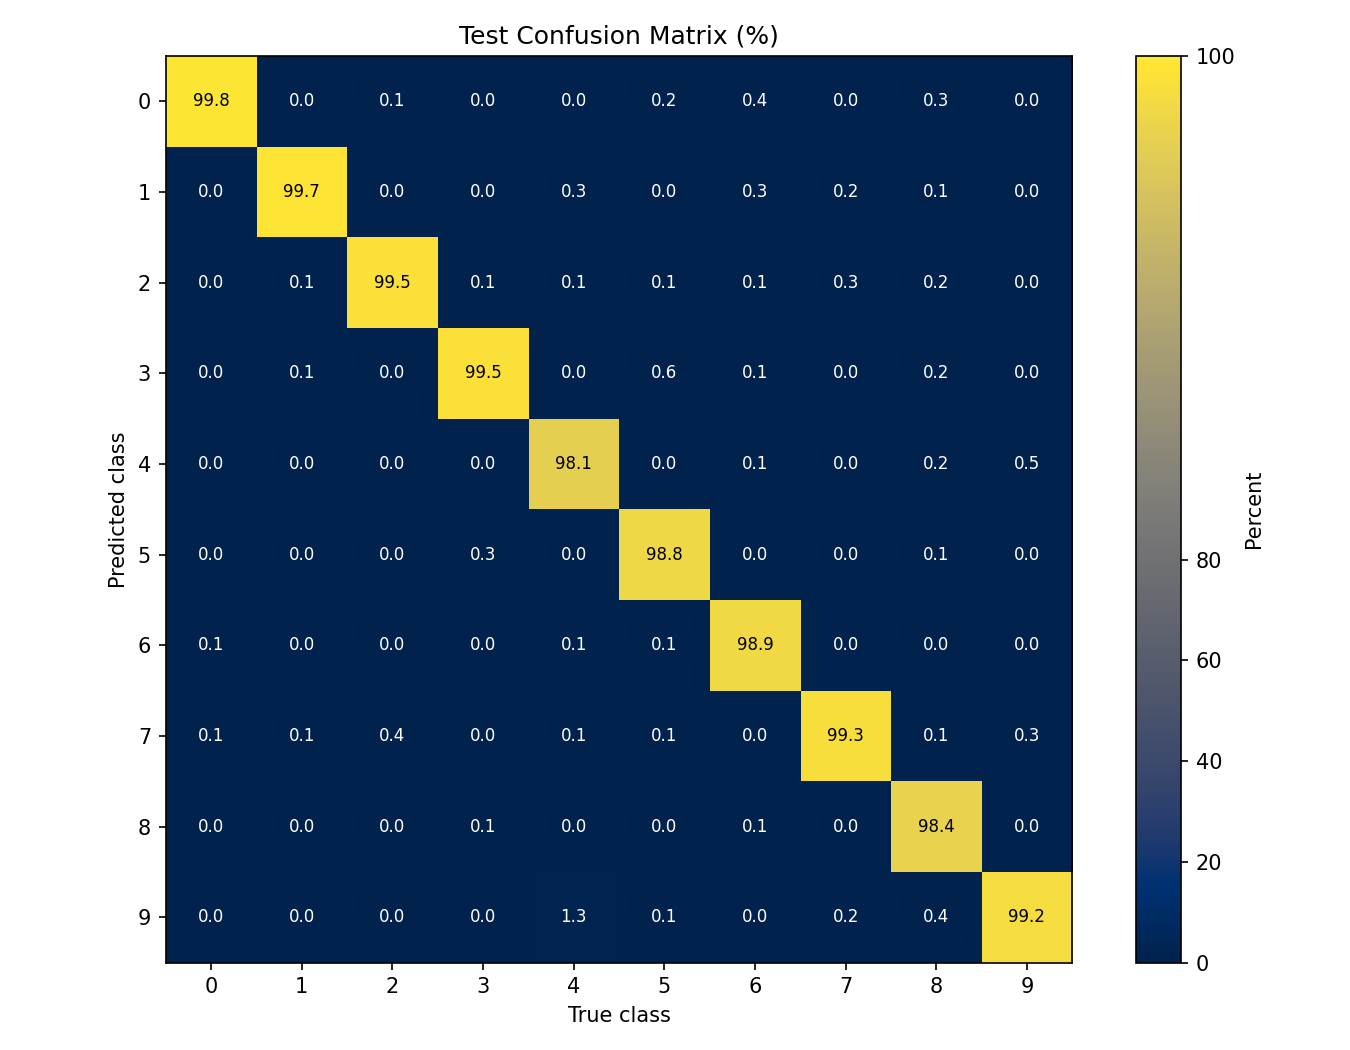


## weight_decay_only


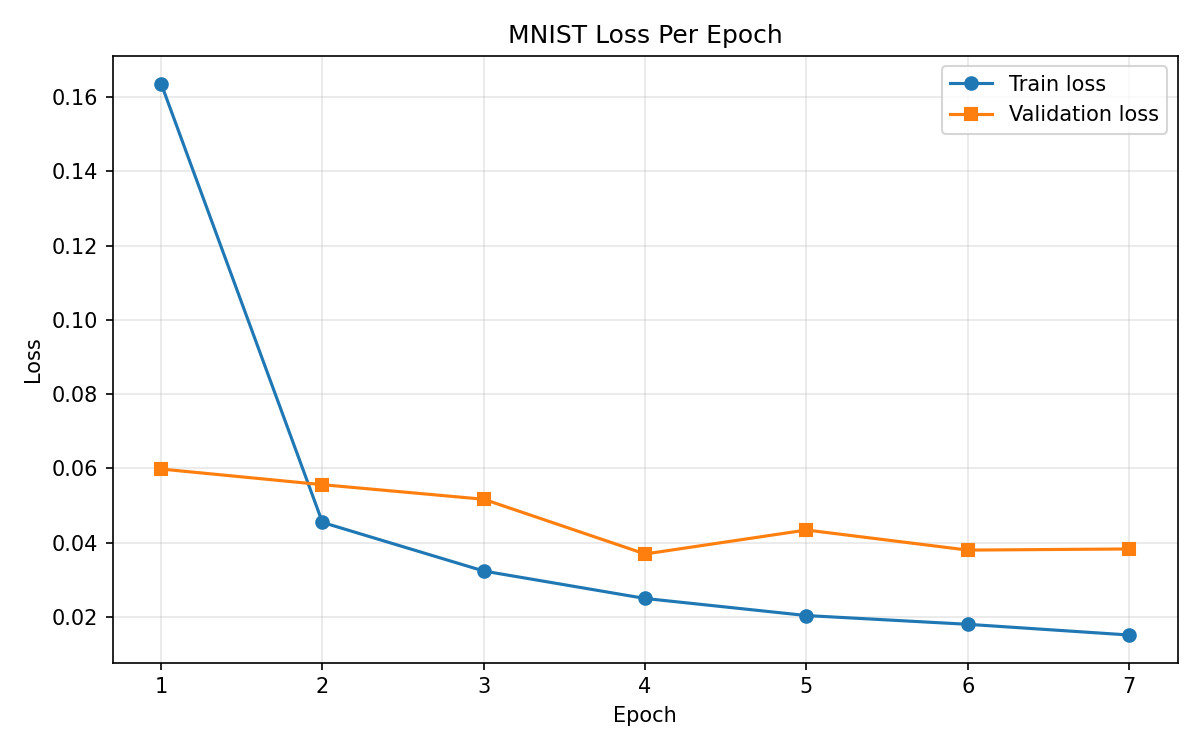

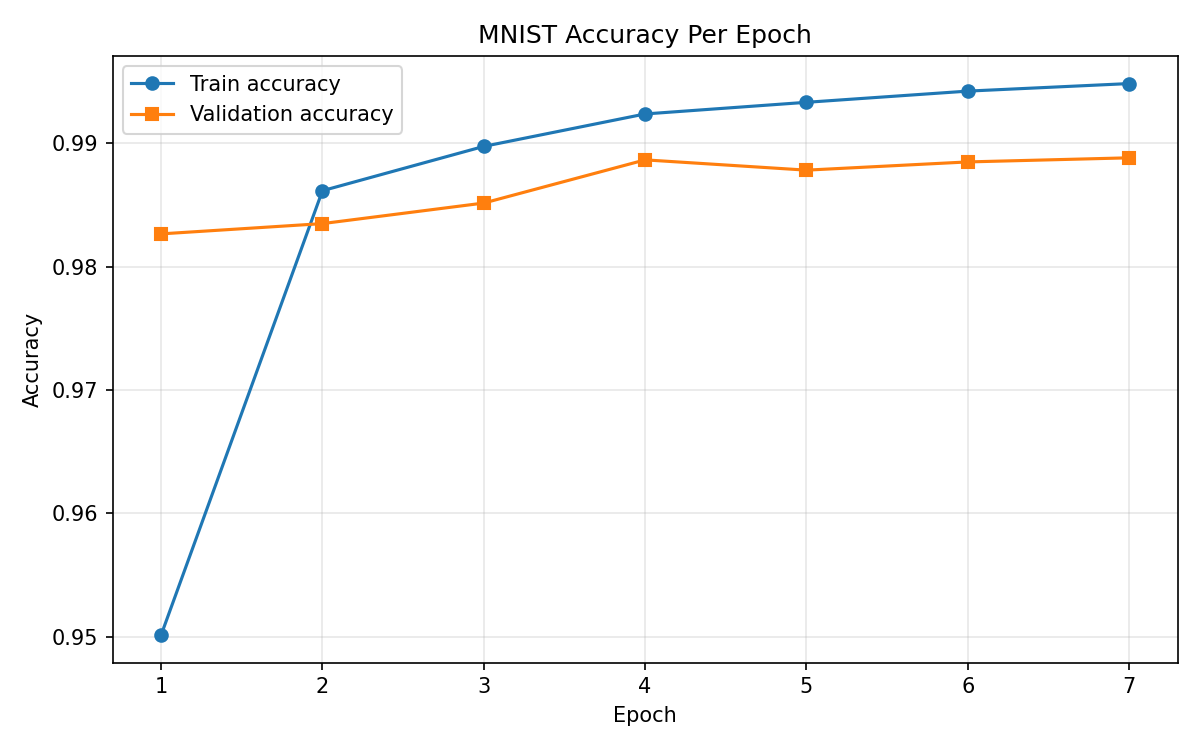

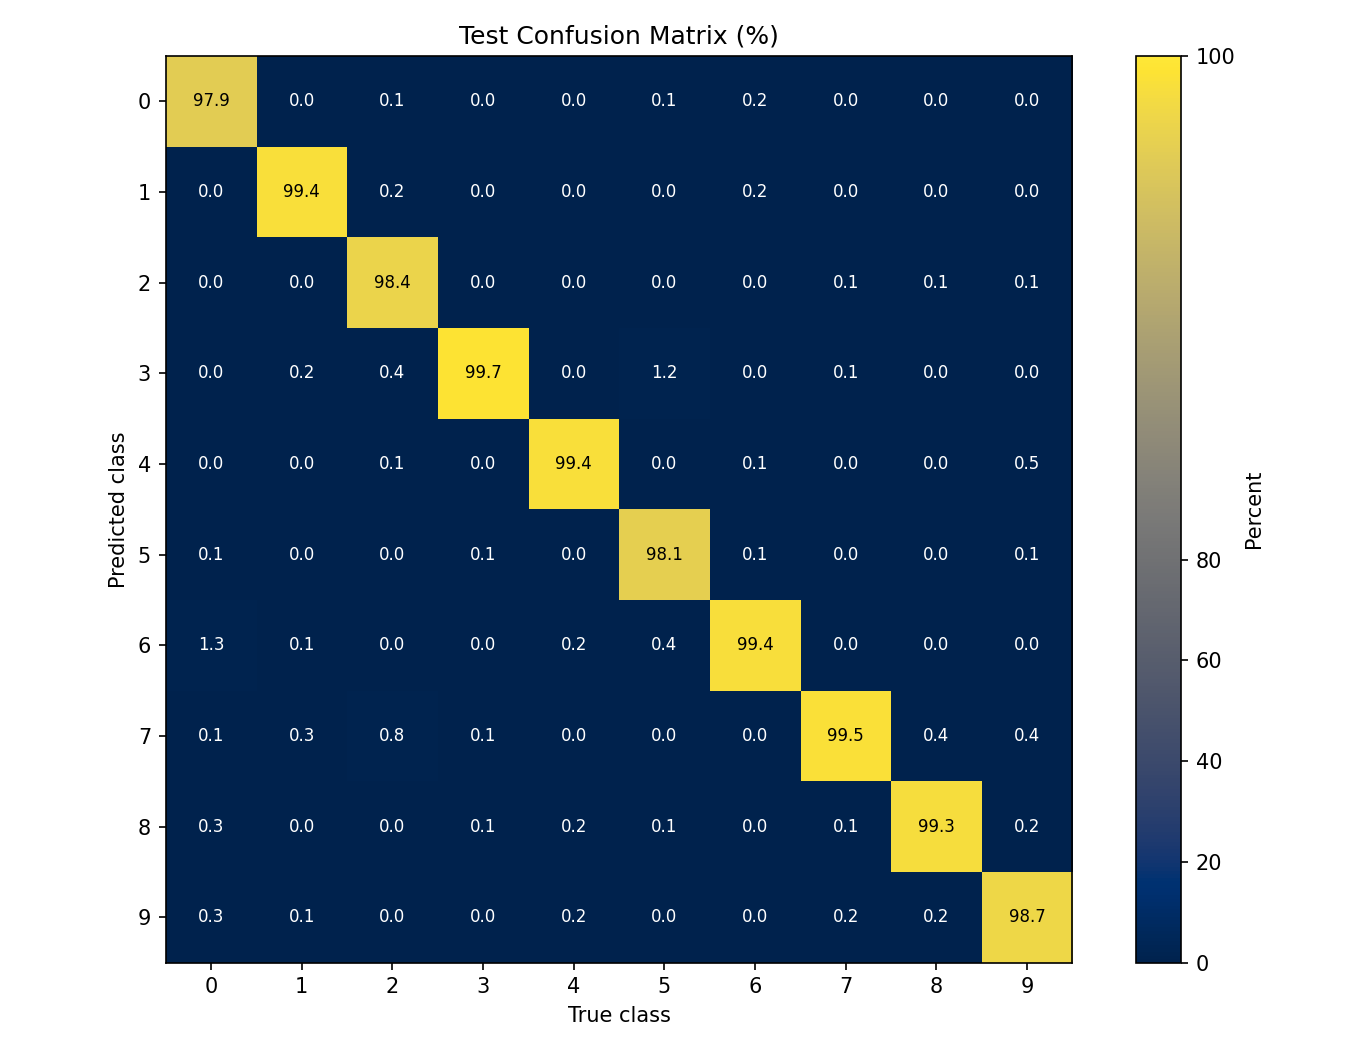


## l1_only


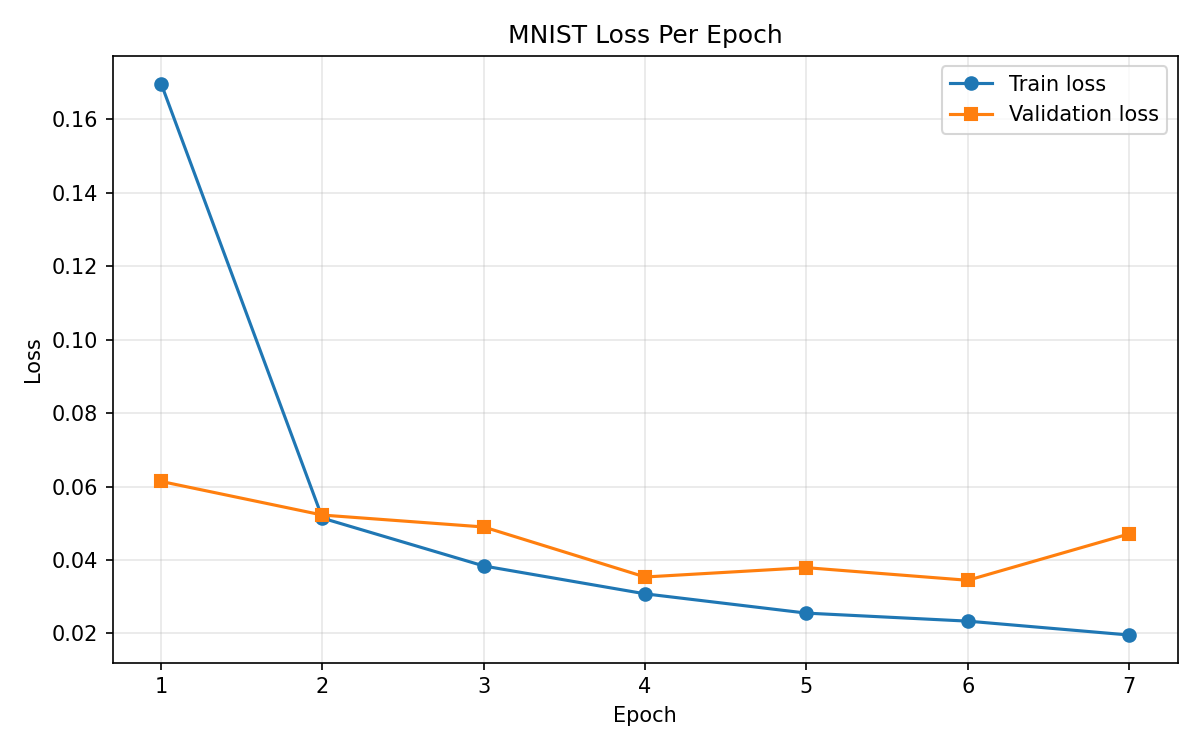

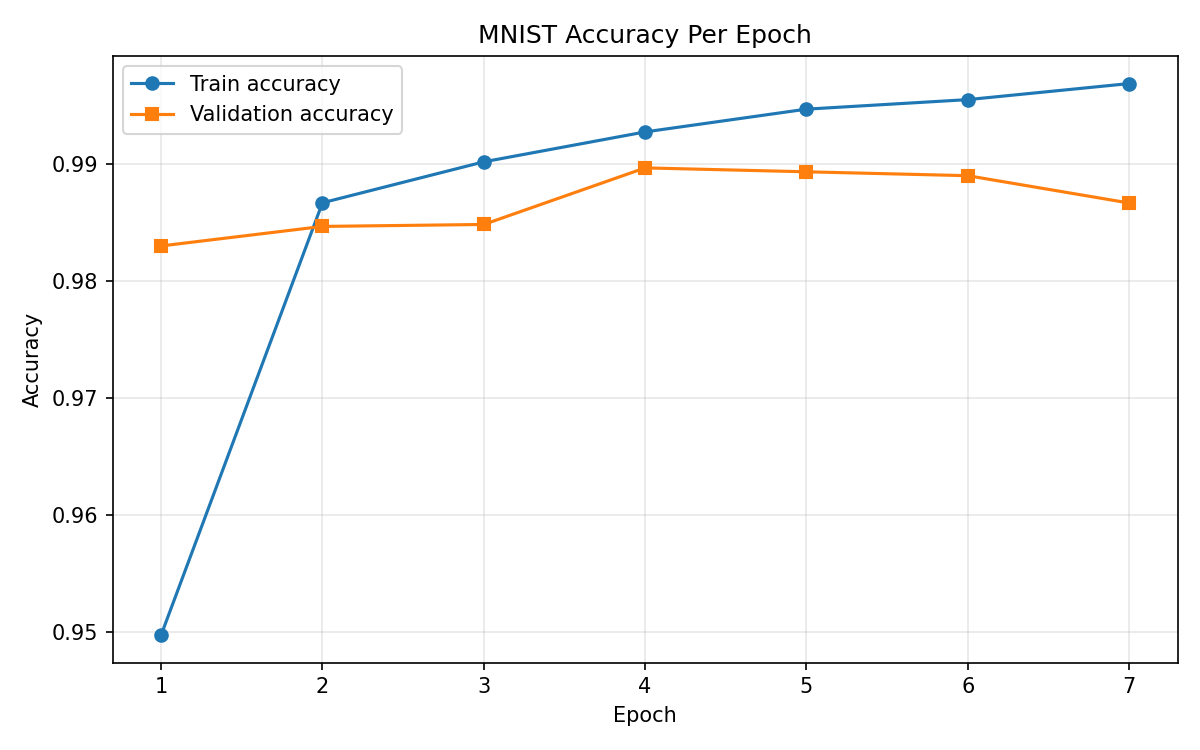

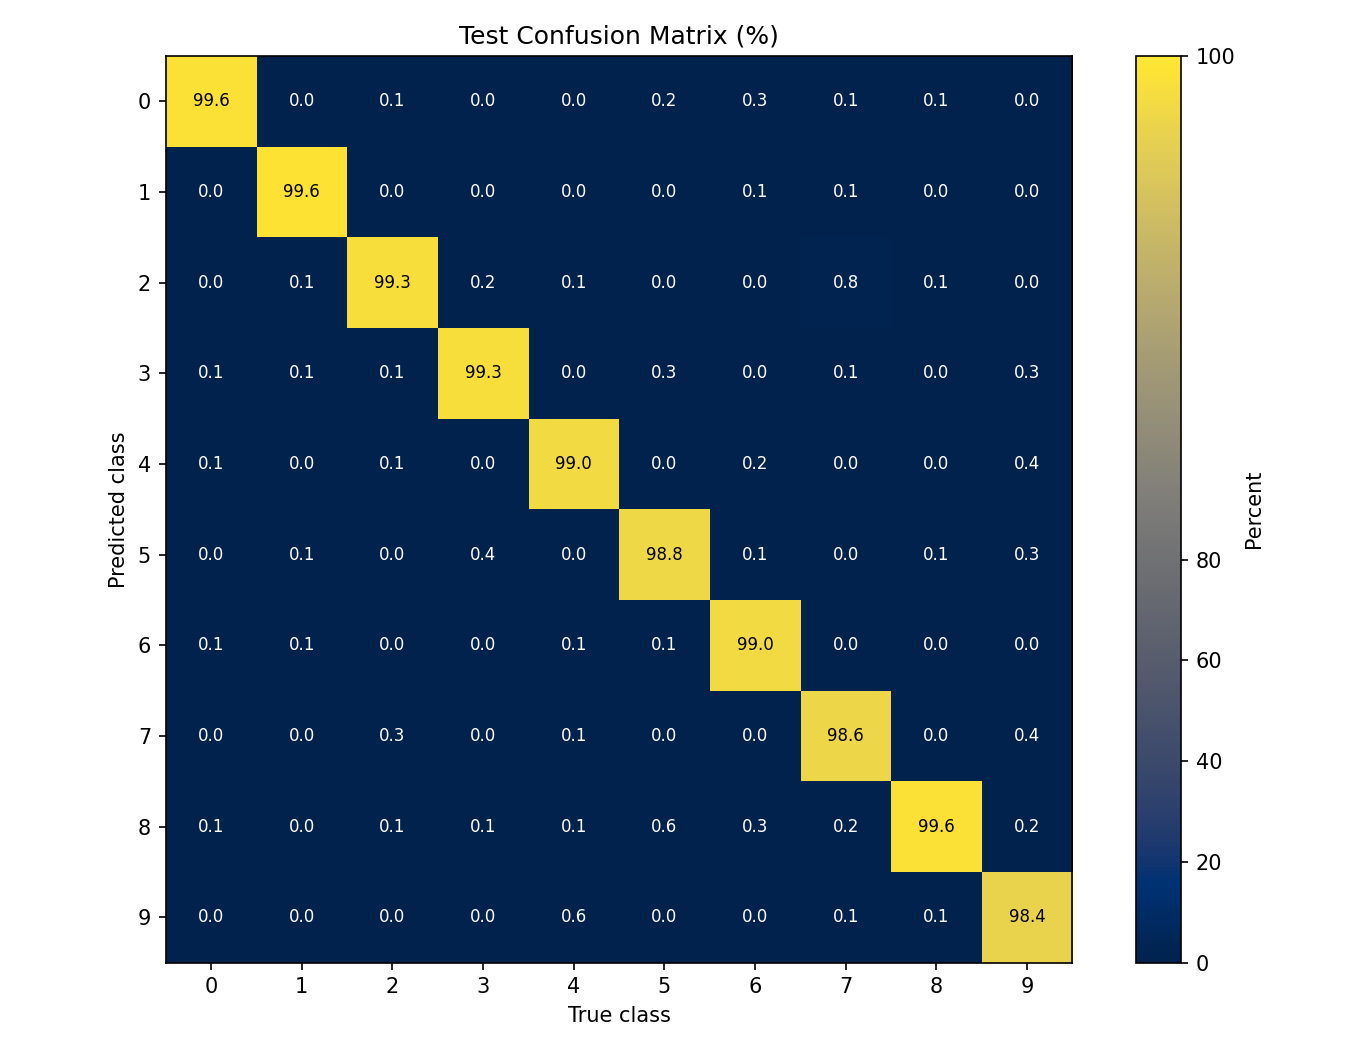


## combined_regularization


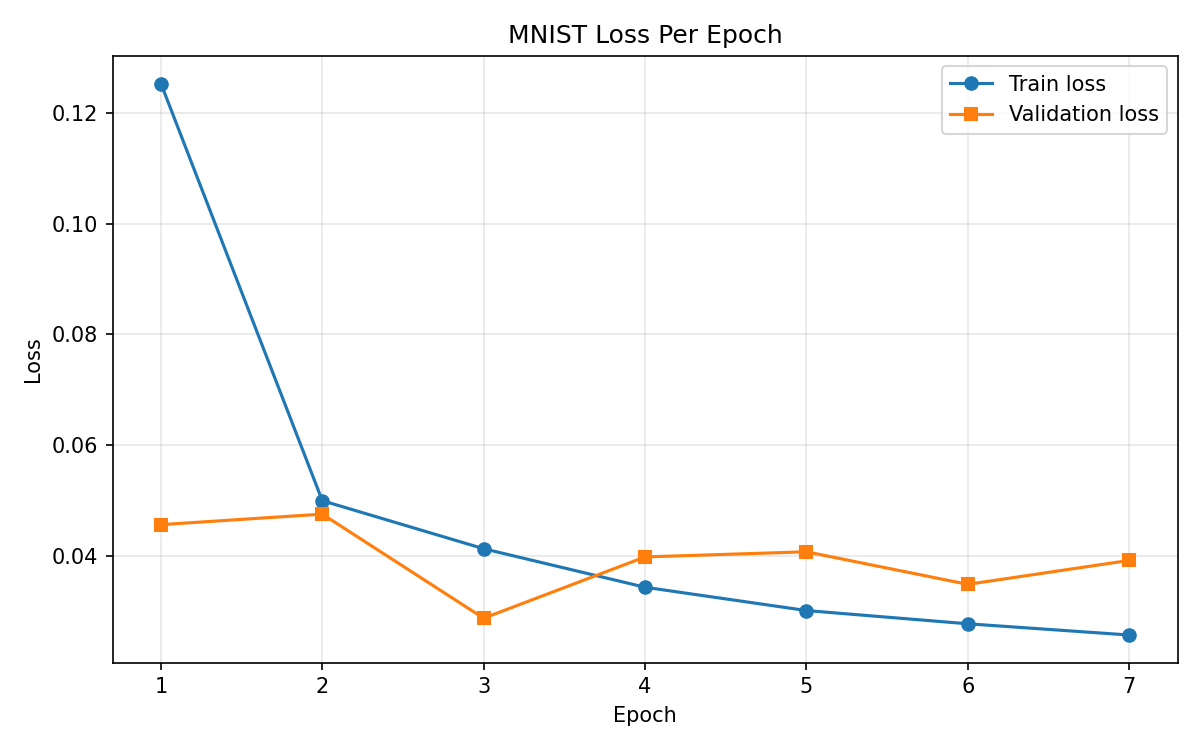

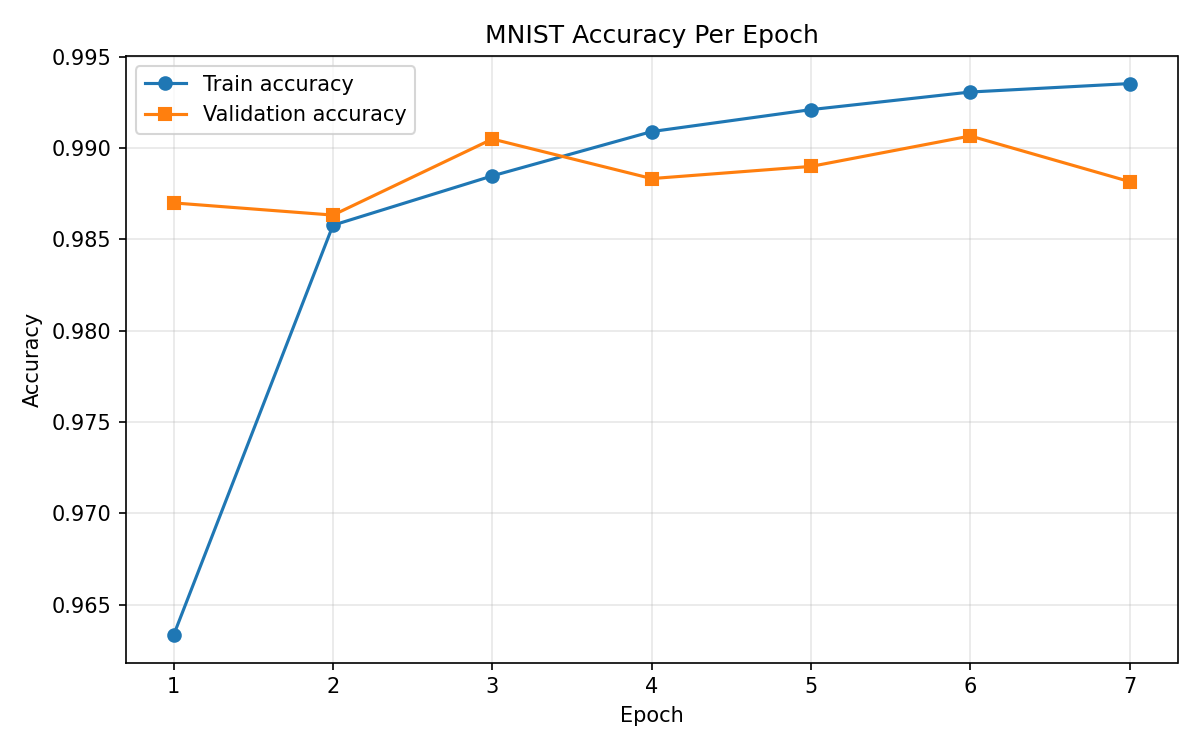

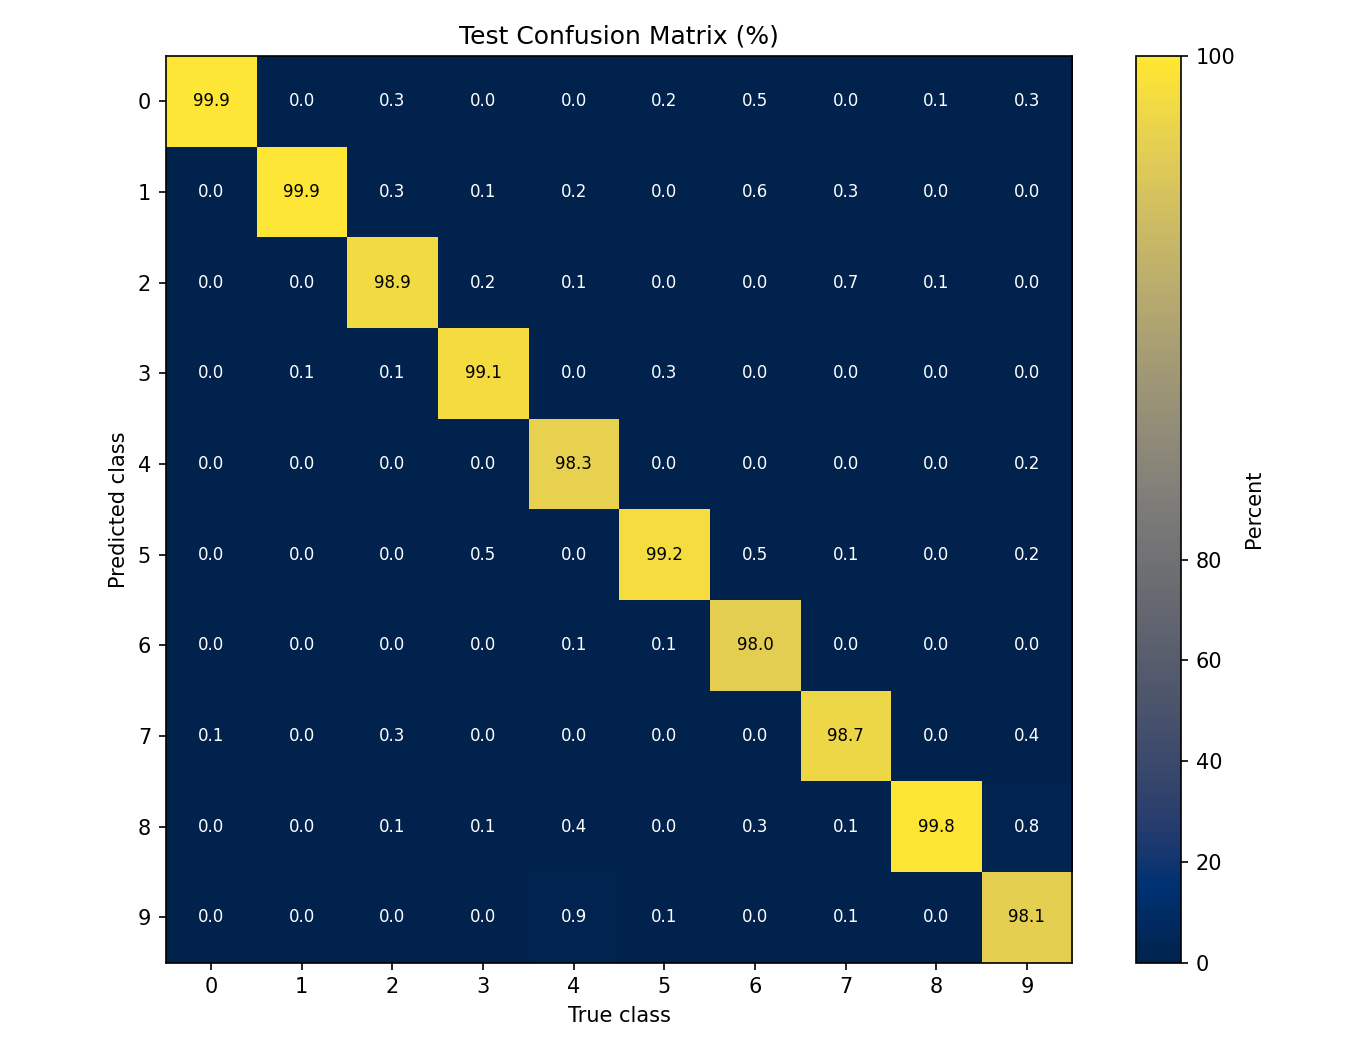

In [5]:
plot_files = ['loss_curve.png', 'accuracy_curve.png', 'confusion_matrix.png']
for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    print(f'\n## {run_name}')
    for plot_name in plot_files:
        display(Image(filename=str(run_dir / plot_name)))


## Final Summary

This section is generated from the saved metrics for the current comparison run.

In [6]:
best_test = max(rows, key=lambda row: row['test_acc'])
best_val_loss = min(rows, key=lambda row: row['best_val_loss'])
fastest = min(rows, key=lambda row: row['time_s'])
baseline = next((row for row in rows if row['run'] == 'baseline'), None)

lines = [
    'English summary:',
    (
        f"Best test accuracy: {best_test['run']} ({best_test['test_acc']:.2%}). "
        f"Best validation loss: {best_val_loss['run']} ({best_val_loss['best_val_loss']:.4f}). "
        f"Fastest run: {fastest['run']} ({fastest['time_s']:.2f}s)."
    ),
]

if baseline is not None and best_test['run'] != 'baseline':
    gap = best_test['test_acc'] - baseline['test_acc']
    lines.append(
        f"Compared with the baseline, the best-test run changes accuracy by {gap:+.2%}."
    )
elif baseline is not None:
    lines.append('The baseline run remained the strongest model on the test set in this comparison.')

print('\n'.join(lines))
lines

English summary:
Best test accuracy: dropout_only (99.21%). Best validation loss: combined_regularization (0.0286). Fastest run: baseline (52.88s).
Compared with the baseline, the best-test run changes accuracy by +0.12%.


['English summary:',
 'Best test accuracy: dropout_only (99.21%). Best validation loss: combined_regularization (0.0286). Fastest run: baseline (52.88s).',
 'Compared with the baseline, the best-test run changes accuracy by +0.12%.']